# Sales Performance & Ranking Analysis

This notebook demonstrates advanced T-SQL patterns for sales performance analysis using the AdventureWorksDW2022 data warehouse.

**Questions covered:**
1. Top Products by Revenue per Year
2. Sales Rep Performance Ranking
3. Product Category Revenue Distribution
4. Best & Worst Performing Territories (YoY Growth)

## Setup

Connect to SQL Server and configure display options.

In [1]:
import urllib
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Database connection - adjust server name as needed
server = 'localhost'
database = 'AdventureWorksDW2022'
conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'
conn_url = f'mssql+pyodbc:///?odbc_connect={urllib.parse.quote_plus(conn_str)}'
engine = create_engine(conn_url)
print('Connected to AdventureWorksDW2022')

Connected to AdventureWorksDW2022


---
## Q1: Top Products by Revenue per Year

**Business Question:** Identify the top 5 products by revenue for each calendar year, showing their rank and revenue contribution percentage.

**Key Techniques:**
- `DENSE_RANK()` for ranking (handles ties without gaps)
- `SUM() OVER (PARTITION BY)` for calculating yearly totals
- CTEs for step-by-step calculation

In [2]:
q1_sql = """
WITH ProductRevenue AS (	
    SELECT 
        fis.ProductKey,
        dd.CalendarYear,
        SUM(fis.SalesAmount) AS TotalRevenue
    FROM dbo.FactInternetSales fis
    INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
    GROUP BY fis.ProductKey, dd.CalendarYear
),
RankedProducts AS (
    SELECT 
        ProductKey,
        CalendarYear,
        TotalRevenue,
        SUM(TotalRevenue) OVER (PARTITION BY CalendarYear) AS YearlyRevenue,
        DENSE_RANK() OVER (PARTITION BY CalendarYear ORDER BY TotalRevenue DESC) AS RevenueRank
    FROM ProductRevenue
)
SELECT
    CalendarYear,
    p.EnglishProductName AS Product,
    TotalRevenue,
    YearlyRevenue,
    RevenueRank,
    TotalRevenue / NULLIF(YearlyRevenue, 0) * 100 AS RevenueContributionPct
FROM RankedProducts rp
INNER JOIN dbo.DimProduct p ON rp.ProductKey = p.ProductKey
WHERE RevenueRank <= 5
ORDER BY CalendarYear, RevenueRank
"""

df_q1 = pd.read_sql(q1_sql, engine)
df_q1

,CalendarYear,Product,TotalRevenue,YearlyRevenue,RevenueRank,RevenueContributionPct
0,2010,"Mountain-100 Silver, 44","10,199.97","43,421.04",1,23.49
1,2010,"Road-150 Red, 62","7,156.54","43,421.04",2,16.48
2,2010,"Road-150 Red, 48","7,156.54","43,421.04",2,16.48
3,2010,"Road-150 Red, 44","3,578.27","43,421.04",3,8.24
4,2010,"Road-150 Red, 52","3,578.27","43,421.04",3,8.24
5,2010,"Road-150 Red, 56","3,578.27","43,421.04",3,8.24
6,2010,"Mountain-100 Silver, 38","3,399.99","43,421.04",4,7.83
7,2010,"Mountain-100 Black, 48","3,374.99","43,421.04",5,7.77
8,2011,"Road-150 Red, 48","1,198,720.45","7,075,525.93",1,16.94
9,2011,"Road-150 Red, 62","1,195,142.18","7,075,525.93",2,16.89


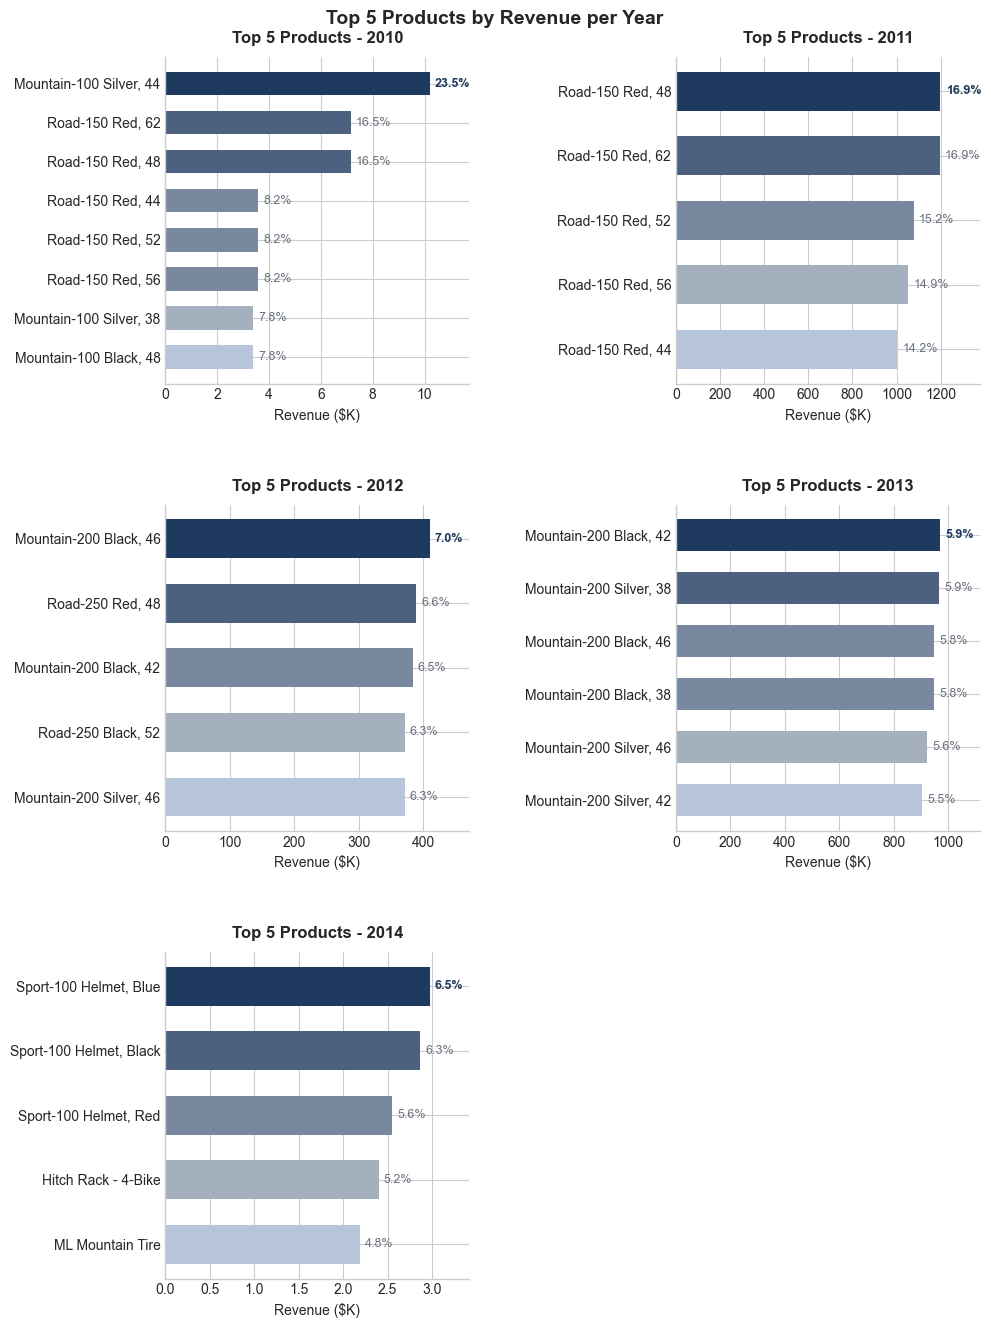

In [3]:
# Visualization: Top 5 Products Revenue by Year
years = sorted(df_q1['CalendarYear'].unique())
n_years = len(years)

# 2 columns for a wider, rectangular layout
n_cols = 2
n_rows = (n_years + n_cols - 1) // n_cols

# Figsize: Bar width and height (10 width, 4.5 height)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4.5 * n_rows))
axes = axes.flatten()

# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']
HIGHLIGHT_COLOR = THEME_COLORS[0]  # Primary for top rank
MUTED_COLOR = THEME_COLORS[4]      # Fifth for lower ranks

for idx, year in enumerate(years):
    ax = axes[idx]
    year_data = df_q1[df_q1['CalendarYear'] == year].sort_values('RevenueRank')
    
    # Map ranks to hierarchical colors
    def get_rank_color(rank):
        if rank <= len(THEME_COLORS):
            return THEME_COLORS[rank - 1]
        return THEME_COLORS[-1]
    colors = [get_rank_color(rank) for rank in year_data['RevenueRank']]
    
    bars = ax.barh(year_data['Product'], year_data['TotalRevenue'] / 1000, color=colors, height=0.6)
    
    ax.set_xlabel('Revenue ($K)')
    ax.set_title(f'Top 5 Products - {year}', fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    max_width = max(bar.get_width() for bar in bars)
    padding = max_width * 0.02
    
    ax.set_xlim(0, max_width * 1.15)

    for bar, pct, rank in zip(bars, year_data['RevenueContributionPct'], year_data['RevenueRank']):
        label_color = THEME_COLORS[0] if rank == 1 else '#6b7280'
        weight = 'bold' if rank == 1 else 'normal'
        
        ax.text(bar.get_width() + padding, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center', fontsize=9, color=label_color, fontweight=weight)

# Hide empty subplots
for idx in range(n_years, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Top 5 Products by Revenue per Year', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(h_pad=4.0, w_pad=4.0)
plt.show()

---
## Q2: Sales Rep Performance Ranking

**Business Question:** Rank sales representatives by quarterly revenue, showing their rank change compared to the previous quarter.

**Key Techniques:**
- `LAG()` for previous quarter comparison
- `DENSE_RANK()` for quarterly rankings
- `CONCAT_WS()` for null-safe string concatenation

In [4]:
q2_sql = """
WITH SalesRepRevenue AS (
    SELECT 
        rs.EmployeeKey,
        e.FirstName,
        e.LastName,
        dd.CalendarYear,
        dd.CalendarQuarter,
        SUM(SalesAmount) AS QuarterlySales
    FROM dbo.FactResellerSales rs
    INNER JOIN dbo.DimEmployee e ON rs.EmployeeKey = e.EmployeeKey
    INNER JOIN dbo.DimDate dd ON rs.OrderDateKey = dd.DateKey
    WHERE e.SalesPersonFlag = 1
    GROUP BY rs.EmployeeKey, e.FirstName, e.LastName, dd.CalendarYear, dd.CalendarQuarter
),
SalesRepCurrentRanking AS (
    SELECT 
        EmployeeKey,
        CONCAT_WS(' ', FirstName, LastName) AS SalesRepName,
        CalendarYear,
        CalendarQuarter,
        QuarterlySales,
        LAG(QuarterlySales) OVER (PARTITION BY EmployeeKey ORDER BY CalendarYear, CalendarQuarter) AS PreviousQuarterSales,
        DENSE_RANK() OVER (PARTITION BY CalendarYear, CalendarQuarter ORDER BY QuarterlySales DESC) AS CurrentRank
    FROM SalesRepRevenue
),
SalesRepPreviousRanking AS (
    SELECT 
        EmployeeKey,
        SalesRepName,
        CalendarYear,
        CalendarQuarter,
        QuarterlySales,
        PreviousQuarterSales,
        QuarterlySales - PreviousQuarterSales AS QuarterlySalesChange,
        CurrentRank,
        LAG(CurrentRank) OVER (PARTITION BY EmployeeKey ORDER BY CalendarYear, CalendarQuarter) AS PreviousRank
    FROM SalesRepCurrentRanking
)
SELECT 
    CalendarYear,
    CalendarQuarter AS Quarter,
    SalesRepName,
    QuarterlySales,
    PreviousQuarterSales,
    QuarterlySalesChange,
    CurrentRank,
    PreviousRank,
    CurrentRank - ISNULL(PreviousRank, CurrentRank) AS RankChange
FROM SalesRepPreviousRanking
ORDER BY CalendarYear, CalendarQuarter, QuarterlySales DESC
"""

df_q2 = pd.read_sql(q2_sql, engine)
df_q2.head(20)

,CalendarYear,Quarter,SalesRepName,QuarterlySales,PreviousQuarterSales,QuarterlySalesChange,CurrentRank,PreviousRank,RankChange
0,2010,4,José Saraiva,"106,251.73",NaN,NaN,1,NaN,0
1,2010,4,Tsvi Reiter,"104,419.33",NaN,NaN,2,NaN,0
2,2010,4,David Campbell,"69,473.00",NaN,NaN,3,NaN,0
3,2010,4,Michael Blythe,"63,762.92",NaN,NaN,4,NaN,0
4,2010,4,Shu Ito,"59,708.32",NaN,NaN,5,NaN,0
5,2010,4,Jillian Carson,"46,695.56",NaN,NaN,6,NaN,0
6,2010,4,Pamela Ansman-Wolfe,"24,432.61",NaN,NaN,7,NaN,0
7,2010,4,Garrett Vargas,"9,109.17",NaN,NaN,8,NaN,0
8,2010,4,Linda Mitchell,"5,475.95",NaN,NaN,9,NaN,0
9,2011,1,Tsvi Reiter,"579,333.19","104,419.33","474,913.86",1,2.00,-1


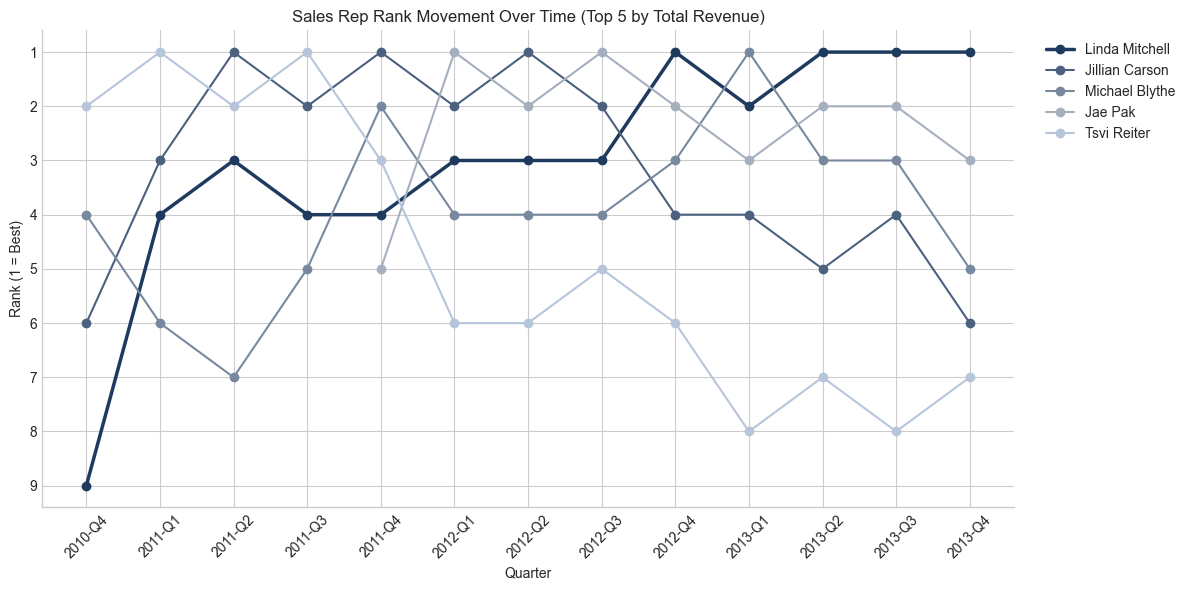

In [5]:
# Visualization: Sales Rep Rank Movement (Top 5 reps)
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']

top_reps = df_q2.groupby('SalesRepName')['QuarterlySales'].sum().nlargest(5).index.tolist()
df_top = df_q2[df_q2['SalesRepName'].isin(top_reps)].copy()
df_top['Period'] = df_top['CalendarYear'].astype(str) + '-Q' + df_top['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
for i, rep in enumerate(top_reps):
    rep_data = df_top[df_top['SalesRepName'] == rep]
    color = THEME_COLORS[i] if i < len(THEME_COLORS) else THEME_COLORS[-1]
    linewidth = 2.5 if i == 0 else 1.5
    ax.plot(rep_data['Period'], rep_data['CurrentRank'], marker='o', label=rep, 
            linewidth=linewidth, color=color)

ax.set_xlabel('Quarter')
ax.set_ylabel('Rank (1 = Best)')
ax.set_title('Sales Rep Rank Movement Over Time (Top 5 by Total Revenue)')
ax.invert_yaxis()
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Q3: Product Category Revenue Distribution

**Business Question:** Calculate what percentile each product falls into based on total revenue (percentile analysis within category).

**Key Techniques:**
- `PERCENT_RANK()` for statistical distribution (preferred over NTILE for skewed data)
- Multi-level dimension joins (Product -> Subcategory -> Category)

In [6]:
q3_sql = """
WITH ProductRevenue AS (
    SELECT 
        ProductKey,
        SUM(SalesAmount) AS TotalRevenue
    FROM dbo.FactInternetSales
    GROUP BY ProductKey
),
ProductDistribution AS (
    SELECT 
        cat.EnglishProductCategoryName AS Category,
        p.EnglishProductName AS Product,
        TotalRevenue,
        PERCENT_RANK() OVER (
            PARTITION BY cat.EnglishProductCategoryName
            ORDER BY TotalRevenue
        ) AS RevenuePercentile
    FROM ProductRevenue pr
    INNER JOIN dbo.DimProduct p ON pr.ProductKey = p.ProductKey
    INNER JOIN dbo.DimProductSubcategory sub ON p.ProductSubcategoryKey = sub.ProductSubcategoryKey
    INNER JOIN dbo.DimProductCategory cat ON sub.ProductCategoryKey = cat.ProductCategoryKey
)
SELECT 
    Category,
    Product,
    TotalRevenue,
    RevenuePercentile * 100 AS RevenuePercentile,
    CASE 
        WHEN RevenuePercentile >= 0.90 THEN 'Tier 1: Top 10%'
        WHEN RevenuePercentile >= 0.75 THEN 'Tier 2: Top 25%'
        WHEN RevenuePercentile >= 0.50 THEN 'Tier 3: Above Average'
        ELSE 'Tier 4: Below Average'
    END AS PerformanceTier
FROM ProductDistribution
ORDER BY Category, TotalRevenue DESC
"""

df_q3 = pd.read_sql(q3_sql, engine)
df_q3.head(15)

,Category,Product,TotalRevenue,RevenuePercentile,PerformanceTier
0,Accessories,"Sport-100 Helmet, Red","78,027.70",100.00,Tier 1: Top 10%
1,Accessories,"Sport-100 Helmet, Blue","74,353.75",95.24,Tier 1: Top 10%
2,Accessories,"Sport-100 Helmet, Black","72,954.15",90.48,Tier 1: Top 10%
3,Accessories,HL Mountain Tire,"48,860.00",85.71,Tier 2: Top 25%
4,Accessories,Fender Set - Mountain,"46,619.58",80.95,Tier 2: Top 25%
5,Accessories,Hydration Pack - 70 oz.,"40,307.67",76.19,Tier 2: Top 25%
6,Accessories,All-Purpose Bike Stand,"39,591.00",71.43,Tier 3: Above Average
7,Accessories,Hitch Rack - 4-Bike,"39,360.00",66.67,Tier 3: Above Average
8,Accessories,ML Mountain Tire,"34,818.39",61.90,Tier 3: Above Average
9,Accessories,HL Road Tire,"27,970.80",57.14,Tier 3: Above Average


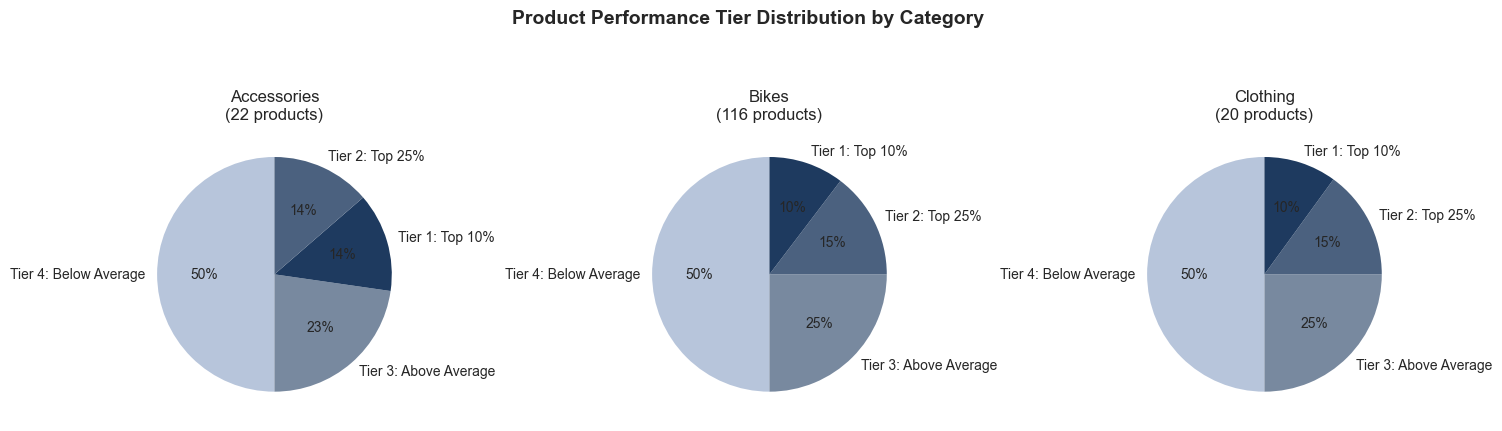

In [7]:
# Visualization: Revenue Distribution by Category with Tier coloring
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tier_colors = {'Tier 1: Top 10%': '#1E3A5F', 'Tier 2: Top 25%': '#4B617F', 
               'Tier 3: Above Average': '#78899F', 'Tier 4: Below Average': '#B7C5DB'}

for idx, category in enumerate(df_q3['Category'].unique()):
    ax = axes[idx]
    cat_data = df_q3[df_q3['Category'] == category]
    
    # Box plot of revenue distribution
    tier_counts = cat_data['PerformanceTier'].value_counts()
    colors = [tier_colors[t] for t in tier_counts.index]
    ax.pie(tier_counts, labels=tier_counts.index, autopct='%1.0f%%', colors=colors, startangle=90)
    ax.set_title(f'{category}\n({len(cat_data)} products)')

plt.suptitle('Product Performance Tier Distribution by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q4: Best & Worst Performing Territories (YoY Growth)

**Business Question:** Rank territories by revenue growth rate year-over-year, identifying top 3 and bottom 3 performers.

**Key Techniques:**
- `LAG()` for year-over-year comparison
- Dual `DENSE_RANK()` for simultaneous top/bottom ranking
- Consecutive year validation (`WHERE PreviousYear = CalendarYear - 1`)

In [8]:
q4_sql = """
WITH TerritoryRevenue AS (
    SELECT 
        dd.CalendarYear,
        st.SalesTerritoryCountry,
        SUM(fis.SalesAmount) AS YearlyRevenue
    FROM dbo.FactInternetSales fis
    INNER JOIN dbo.DimDate dd ON fis.OrderDateKey = dd.DateKey
    INNER JOIN dbo.DimSalesTerritory st ON fis.SalesTerritoryKey = st.SalesTerritoryKey
    WHERE SalesTerritoryCountry IS NOT NULL AND SalesTerritoryCountry <> 'NA'
    GROUP BY dd.CalendarYear, st.SalesTerritoryCountry
),
YoYGrowthStats AS (
    SELECT 
        CalendarYear,
        SalesTerritoryCountry,
        YearlyRevenue,
        LAG(YearlyRevenue) OVER (PARTITION BY SalesTerritoryCountry ORDER BY CalendarYear) AS PreviousYearRevenue,
        LAG(CalendarYear) OVER (PARTITION BY SalesTerritoryCountry ORDER BY CalendarYear) AS PreviousYear
    FROM TerritoryRevenue
),
YoYGrowthRanked AS (
    SELECT 
        CalendarYear,
        PreviousYear,
        SalesTerritoryCountry,
        YearlyRevenue,
        PreviousYearRevenue,
        YearlyRevenue - PreviousYearRevenue AS YoYChange,
        (YearlyRevenue - PreviousYearRevenue) / NULLIF(PreviousYearRevenue, 0) * 100 AS YoYGrowthRate,
        DENSE_RANK() OVER (PARTITION BY CalendarYear ORDER BY (YearlyRevenue - PreviousYearRevenue) / NULLIF(PreviousYearRevenue, 0) DESC) AS TopRank,
        DENSE_RANK() OVER (PARTITION BY CalendarYear ORDER BY (YearlyRevenue - PreviousYearRevenue) / NULLIF(PreviousYearRevenue, 0) ASC) AS BottomRank
    FROM YoYGrowthStats
    WHERE PreviousYear = CalendarYear - 1 AND PreviousYearRevenue IS NOT NULL
)
SELECT 
    CalendarYear,
    SalesTerritoryCountry AS Country,
    YearlyRevenue,
    PreviousYearRevenue,
    YoYChange,
    YoYGrowthRate,
    CASE 
        WHEN TopRank <= 3 THEN 'Top ' + CAST(TopRank AS VARCHAR)
        WHEN BottomRank <= 3 THEN 'Bottom ' + CAST(BottomRank AS VARCHAR)
    END AS PerformanceCategory
FROM YoYGrowthRanked
WHERE TopRank <= 3 OR BottomRank <= 3
ORDER BY CalendarYear, YoYGrowthRate DESC
"""

df_q4 = pd.read_sql(q4_sql, engine)
df_q4

,CalendarYear,Country,YearlyRevenue,PreviousYearRevenue,YoYChange,YoYGrowthRate,PerformanceCategory
0,2011,United Kingdom,"550,591.22",699.10,"549,892.12","78,657.35",Top 1
1,2011,United States,"2,458,285.17","14,833.90","2,443,451.27","16,472.07",Top 2
2,2011,Canada,"571,571.80","3,578.27","567,993.53","15,873.41",Top 3
3,2011,Australia,"2,563,732.25","20,909.78","2,542,822.47","12,160.92",Bottom 2
4,2011,France,"410,845.33","3,399.99","407,445.34","11,983.72",Bottom 1
5,2012,France,"648,065.54","410,845.33","237,220.21",57.73,Top 1
6,2012,United Kingdom,"712,700.96","550,591.22","162,109.75",29.44,Top 2
7,2012,Germany,"608,657.98","520,500.16","88,157.82",16.93,Top 3
8,2012,Australia,"2,128,407.46","2,563,732.25","-435,324.79",-16.98,Bottom 3
9,2012,United States,"1,437,048.73","2,458,285.17","-1,021,236.44",-41.54,Bottom 2


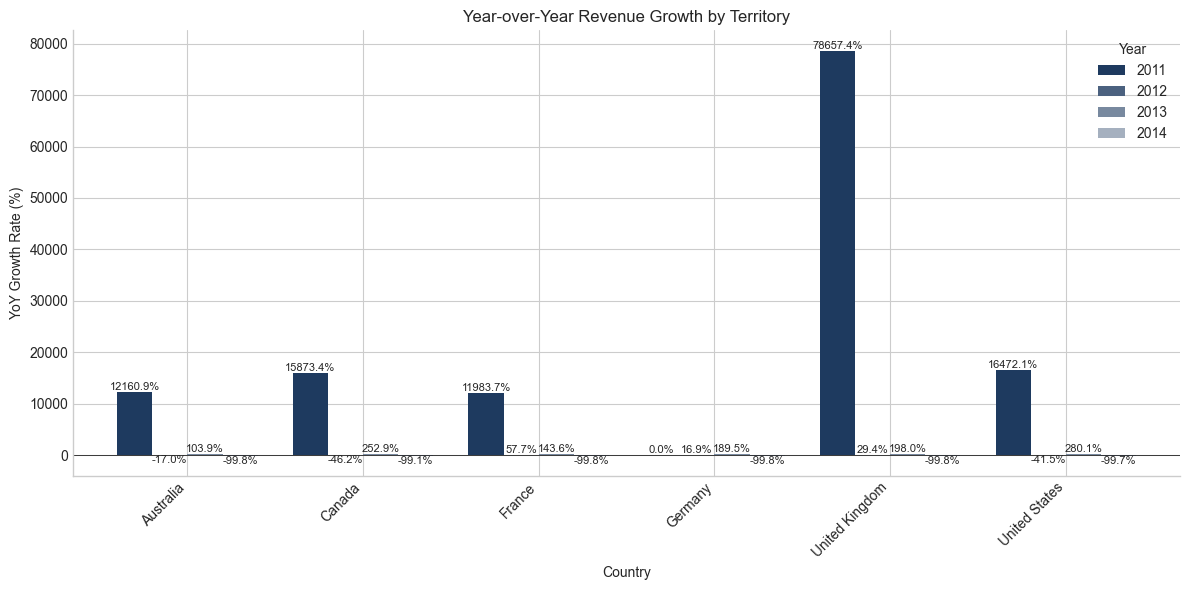

In [9]:
# Visualization: YoY Growth Rate by Territory
# Theme colors (hierarchical: best to worst)
THEME_COLORS = ['#1E3A5F', '#4B617F', '#78899F', '#A5B0BF', '#B7C5DB']

fig, ax = plt.subplots(figsize=(12, 6))

# Pivot for grouped bar chart
pivot_df = df_q4.pivot(index='Country', columns='CalendarYear', values='YoYGrowthRate')

# Assign colors based on year order
years = sorted(pivot_df.columns)
year_colors = {year: THEME_COLORS[i] if i < len(THEME_COLORS) else THEME_COLORS[-1] 
               for i, year in enumerate(years)}
colors = [year_colors[year] for year in pivot_df.columns]

pivot_df.plot(kind='bar', ax=ax, width=0.8, color=colors)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Country')
ax.set_ylabel('YoY Growth Rate (%)')
ax.set_title('Year-over-Year Revenue Growth by Territory')
ax.legend(title='Year')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.show()

---
## Cleanup

In [10]:
engine.dispose()
print('Connection closed')

Connection closed
